This code calculates the electric field components of LSM modes in a dielectric-lined rectangular waveguide. It follows the approach of Xiao L. et. al., 2001, Phys. Rev. E 65 016505.

It also calculates the dispersion curves for a given LSM mode.

I plan to extend this to LSE modes too.

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
from scipy.constants import pi, epsilon_0, c
from scipy.optimize import brentq


Input parameters

In [2]:
# box dimensions
w = 23e-3   # guide width in x   [m]
b = 5.0e-3   # guide height in y  [m]
a = 3.0e-3     # height of the air region (dielectric starts at y=a) [m]
eps_r = 10        # relative permittivity of the slab


f_min, f_max, n_f = 10e9, 15e9, 100 #8GHz -> 15GHz, 300 points calc'ed
# -------------------------------------------------------------

c = c
d = b - a

### Dispersion Curves
Geometry (as in the paper): 
$$
\begin{aligned}
&(a)\quad 0 < x < w \\
&(b)\quad 0 < y < a \\
&(c)\quad a < y < b
\end{aligned}
$$
$(a)$ corresponds to the width of the slab without a dielectric on the sides, $(b)$ corresponds to the vacuum region, $(c)$ corresponds to the dielectric with $\epsilon_r$.

#### Equations in paper
I assigned a substitute variable $s$ to $\sqrt{s}=k_y^{(0)}$, where $k_y^{(1)}=\sqrt{s+(\epsilon_r-1)k^2}$. To make sure the dispersion relation is always real for both sides of $s=0$, divide the dispersion relation by $k_y^{(0)}$ and substitute in $s$. Then, pick limits of $s$ to search for. 

**Why $\beta_{mn}$ is not a second unknown:**
$s$ is only a change of variable, $s=\left(k_y^{(0)}\right)^2$. Subtracting the two expressions for $k_y^{(0)^2}$ and $k_y^{(1)^2}$ (given below) cancels $\beta_{mn}$:
$$
k_y^{(1)^2}-k_y^{(0)^2}=(\epsilon_r-1)k^2 .
$$
So $k_y^{(1)}=\sqrt{s+(\epsilon_r-1)k^2}$ depends on $s$ and $k$ only, and the dispersion relation is a function of $s$ and $k$ only. At a fixed frequency ($k$ known) it is one equation in one unknown, $s$. The relation $s=k^2-\left(\frac{m\pi}{w}\right)^2-\beta_{mn}^2$ is not solved with two unknowns; it is used afterwards, to convert each root $s_n$ into $\beta_{mn}$.

**Why dividing by $k_y^{(0)}$ is valid:**
Write the original relation as $F=-k_y^{(0)}\,G(s)$, where $G$ is the divided form used in the code. For $s\neq0$, $k_y^{(0)}\neq0$, so $F=0$ and $G=0$ have the same roots. At $s=0$, $F$ is zero for any $k$ (a trivial solution, as all the field components vanish there), whereas $G(0)$ is finite, using $\sin(k_y^{(0)}a)/k_y^{(0)}\to a$. $G$ is even in $k_y^{(0)}$, so it is a smooth, real function of $s$ for both $s>0$ (oscillating in the vacuum) and $s<0$ (evanescent in the vacuum, $\sin\to\sinh$, $\cos\to\cosh$).

#### Limits of $s$
Consider $k_y^{(0)}$ and $k_y^{(1)}$. 

Without substituion,
$$
\begin{aligned}
k_y^{(0)^2}=k^2-\left(\frac{m\pi}{w}\right)^2-\beta_{mn}^2 \\
k_y^{(1)^2}=\epsilon_r{k^2}-\left(\frac{m\pi}{w}\right)^2-\beta_{mn}^2
\end{aligned}
$$

In $s$ substitution, $\sqrt{s}=k_y^{(0)}$, where $k_y^{(1)}=\sqrt{s+(\epsilon_r-1)k^2}$.

**Lower limit of s:**
By default $k_y^{(1)^2}>0$, as the field can't decay in both regions or else it won't hit the walls of the waveguide at all (no mode). Therefore,
$$
s=-\left(\epsilon_r-1\right)k^2.
$$    

**Upper limit of s:**
From the original expression for $k_y^{(0)^2}$, 
$$
\begin{aligned}
s = k^2 - \left(\frac{m\pi}{w}\right)^2 - \beta_{mn}^2, \\
\implies \beta_{mn}^2=k^2-\left(\frac{m\pi}{w}\right)^2-s,
\end{aligned}
$$
and we need $\beta_{mn}$ to be real as the propagation term in $\vec{z}$, $\textrm{exp}\left(-j\beta_{mn}z\right)$, will not be a travelling wave otherwise. Therefore I set $\beta_{mn}$ to 0.

#### Calculating $\beta_{mn}$ for different frequencies
I used
$$
\beta_{mn} = \sqrt(k^2-\left(\frac{m\pi}{w}\right)^2-s_n),
$$
where $n$ denotes the number of frequencies used in an array.

#### How code works
Uses the above principles. 

For each frequency $f$:
1. $k=2\pi f/c$ is known.
2. Solve the divided dispersion relation $G(s;k)=0$ for $s$ between the limits above. This gives several roots, one per mode, sorted in ascending order of $s$ (`roots_in_s`). The $n$-th smallest root $s_n$ is the $n$-th mode.
3. Convert the root to $\beta_{mn}$ using $\beta_{mn}^2=k^2-\left(\frac{m\pi}{w}\right)^2-s_n$.

Repeating this for each frequency gives $\beta_{mn}(f)$, the dispersion curve.



LSM11 cutoff = 10.405 GHz
LSM21 cutoff = 11.183 GHz
f range: 9.89 - 15.00 GHz
saved dispersion.png


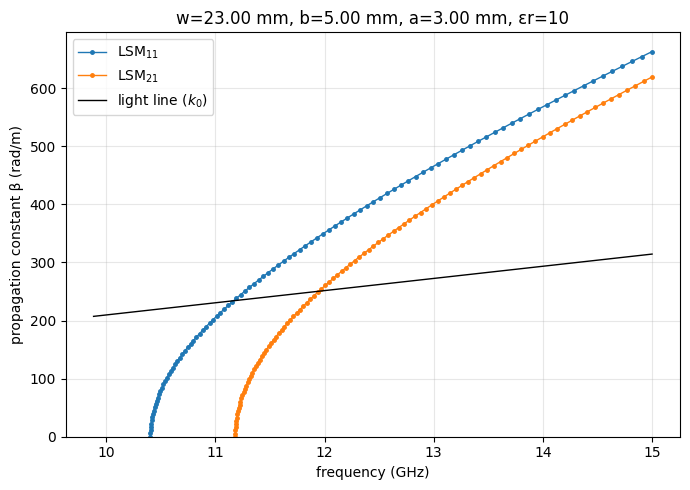

In [ ]:
def _sqrt(q):
    return np.sqrt(complex(q))


def lsm(s, k):
    """
    Eq. (4a) divided by ky0 so it stays real when ky0 is imaginary:
    ky1 sin(ky1 d) * sin(ky0 a)/ky0 - eps_r cos(ky0 a) cos(ky1 d) = 0
    """
    ky0 = _sqrt(s)
    ky1 = _sqrt(s + (eps_r - 1) * k**2)
    sinc0 = np.sin(ky0 * a) / ky0 if abs(ky0) > 1e-12 else a
    val = ky1 * np.sin(ky1 * d) * sinc0 - eps_r * np.cos(ky0 * a) * np.cos(ky1 * d)
    return val.real


def lse(s, k):
    """
    LSE relation  ky0 cot(ky0 a) = -ky1 cot(ky1 d), written pole-free and
    divided by ky0*ky1 so it stays real:
    cos(ky1 d) sin(ky0 a)/ky0 + cos(ky0 a) sin(ky1 d)/ky1 = 0
    (check against the paper's Eq. 4b)
       
    """
    ky0 = _sqrt(s)
    ky1 = _sqrt(s + (eps_r - 1) * k**2)
    sinc0 = np.sin(ky0 * a) / ky0 if abs(ky0) > 1e-12 else a
    sinc1 = np.sin(ky1 * d) / ky1 if abs(ky1) > 1e-12 else d
    val = np.cos(ky1 * d) * sinc0 + np.cos(ky0 * a) * sinc1
    return val.real


def roots_in_s(func, k, n_grid=4000):
    """All roots s = ky0^2, sorted ascending (= descending beta = n = 1, 2, ...)."""
    s_lo = -(eps_r - 1) * k**2 * (1 - 1e-9)   # beta at its max (field all in dielectric)
    s_hi = k**2                                # beta = 0 for m = 0
    grid = np.linspace(s_lo, s_hi, n_grid)
    vals = np.array([func(s, k) for s in grid])
    out = []
    for i in range(n_grid - 1):
        if vals[i] == 0:
            out.append(grid[i])
        elif vals[i] * vals[i + 1] < 0:
            out.append(brentq(func, grid[i], grid[i + 1], args=(k,)))
    return out


def cutoff(func, m, n, n_grid=4000):
    """
    Cutoff frequency of mode (m, n).

    At cutoff beta = 0, so from Eq. (3):  s = ky0^2 = k^2 - (m pi / w)^2.
    Putting that s into the dispersion relation leaves an equation in f only:
        G(f) = F(k^2 - (m pi/w)^2, k) = 0
    The n-th sign change of G as f increases is the cutoff of mode (m, n).
    """
    kx2 = (m * np.pi / w) ** 2
    G = lambda f: func((2*np.pi*f/c)**2 - kx2, 2*np.pi*f/c)

    # Lowest possible cutoff: ky1 must be real, i.e. eps_r k^2 >= kx^2.
    # (For m = 0 this is 0, so start slightly above it.)
    f_lo = c * np.sqrt(kx2) / (2*np.pi*np.sqrt(eps_r)) * (1 + 1e-9) + 1e6
    # upper search limit: bove where n half-waves fit in the air region.
    f_hi = c / 2 * np.sqrt((m/w)**2 + (n/min(a, b - a))**2) * 3 + 1e9

    grid = np.linspace(f_lo, f_hi, n_grid)
    vals = np.array([G(f) for f in grid])
    found = 0
    for i in range(n_grid - 1):
        if vals[i] * vals[i + 1] < 0:
            found += 1
            if found == n:
                return brentq(G, grid[i], grid[i + 1])
    raise ValueError(f"no cutoff found for mode ({m},{n})")


def beta_curve(func, m, n, f_c, f_max):
    """
    beta(f) for mode (m, n), sampled from its own cutoff f_c up to f_max.

    Starting exactly at f_c puts a point at beta=0. Points are packed
    more densely near cutoff, where beta=sqrt(f-f_c) rises steeply
    """
    t = np.linspace(0, 1, n_f)
    freqs = f_c + (f_max - f_c) * t**2      # quadratic spacing
    betas = np.full(n_f, np.nan)
    betas[0] = 0.0                           
    kx2 = (m * np.pi / w) ** 2
    for i, f in enumerate(freqs[1:], start=1):
        k = 2 * np.pi * f / c
        s_roots = roots_in_s(func, k)
        if len(s_roots) >= n:
            beta2 = k**2 - kx2 - s_roots[n - 1]
            if beta2 > 0:
                betas[i] = np.sqrt(beta2)
    return freqs, betas


if __name__ == "__main__":

    # name modes 
    modes = [("LSM", lsm, 1, 1), ("LSM", lsm, 2, 1)]
 
    # define frequency range
    cutoffs = {}

    for name, func, m, n in modes:
        cutoffs[(name, m, n)] = cutoff(func, m, n)
        print(f"{name}{m}{n} cutoff = {cutoffs[(name, m, n)]/1e9:.3f} GHz")

    f_min = 0.95 * min(cutoffs.values())            # just below the first mode

    # make it easier to read
    print(f"f range: {f_min/1e9:.2f} - {f_max/1e9:.2f} GHz")
 
    plt.figure(figsize=(7, 5))
    for name, func, m, n in modes:
        f, bt = beta_curve(func, m, n, cutoffs[(name, m, n)], f_max)
        plt.plot(f / 1e9, bt, marker="o", ms=2.5, lw=1, label=f"{name}$_{{{m}{n}}}$")
 
    f = np.linspace(f_min, f_max, 100)
    plt.plot(f / 1e9, 2 * np.pi * f / c, "k", lw=1, label="light line ($k_0$)")
 
    plt.xlabel("frequency (GHz)")
    plt.ylabel("propagation constant β (rad/m)")
    plt.title(f"w={w*1e3:.2f} mm, b={b*1e3:.2f} mm, a={a*1e3:.2f} mm, εr={eps_r}")
    plt.ylim(bottom=0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("dispersion.png", dpi=150)
    print("saved dispersion.png")
 


## Field components

In [4]:
# --- Field components for the LSM_mn mode (Xiao, Gai & Sun 2001, Eqs. (3), (6), (7)) ---

# pick the mode, then choose the operating frequency: either the frequency at
# which this mode's dispersion curve crosses the light line (beta = k), which
# is the natural synchronous-acceleration operating point for an
# ultrarelativistic beam, or a frequency of your own choosing.
m, n = 1, 1

use_light_line_frequency = True   # False -> use user_frequency instead
user_frequency = None             # Hz, only used when use_light_line_frequency is False


def find_light_line_crossing(func, m, f_lo=f_min, f_hi=f_max, n_grid=20000):
    """
    Frequency at which mode m1's dispersion curve crosses the light line
    (beta = k). At that point ky0^2 = k^2 - kx^2 - beta^2 = -kx^2 for any f,
    so this fixes s = -kx^2 and searches for the f at which the dispersion
    relation func(s, k) = 0 is satisfied.
    """
    kx2 = (m * np.pi / w) ** 2
    s_sync = -kx2
    k_grid = np.linspace(2 * np.pi * f_lo / c, 2 * np.pi * f_hi / c, n_grid)
    vals = np.array([func(s_sync, k) for k in k_grid])
    for i in range(n_grid - 1):
        if vals[i] * vals[i + 1] < 0:
            k_root = brentq(lambda k: func(s_sync, k), k_grid[i], k_grid[i + 1])
            return k_root * c / (2 * np.pi)
    raise ValueError(f"no light-line crossing found for mode m={m} in [{f_lo/1e9:.2f}, {f_hi/1e9:.2f}] GHz")


if use_light_line_frequency:
    frequency = find_light_line_crossing(lsm, m)
    print(f"LSM{m}{n} crosses the light line at f = {frequency/1e9:.4f} GHz")
else:
    if user_frequency is None:
        raise ValueError("set user_frequency (Hz) when use_light_line_frequency is False")
    frequency = user_frequency

# sanity check: this dispersion solver (roots_in_s / beta_curve, defined
# above) and the mode-continuity assumption it relies on (n-th smallest s
# root = n-th mode branch) were only validated over f_min-f_max; well
# outside that band the wrong branch can silently get picked up, so refuse
# rather than return a number that looks plausible but may not be
if not (f_min <= frequency <= 3 * f_max):
    raise ValueError(
        f"f = {frequency/1e9:.3f} GHz is far outside the range this notebook's "
        f"dispersion solver was set up for ({f_min/1e9:.2f}-{f_max/1e9:.2f} GHz). "
        f"Double-check the value (e.g. 105e9 = 105 GHz, not 10.5 GHz) - if it's "
        f"really intended, results here are not reliable that far from cutoff."
    )

k = 2 * np.pi * frequency / c
omega = 2 * np.pi * frequency

# get beta_mn by reusing the dispersion-curve calculation from the cells
# above (cutoff + beta_curve) instead of re-deriving it here
f_c = cutoff(lsm, m, n)
if frequency < f_c:
    raise ValueError(f"f = {frequency/1e9:.3f} GHz is below the LSM{m}{n} cutoff "
                      f"({f_c/1e9:.3f} GHz) - mode does not propagate there")

freqs_curve, betas_curve = beta_curve(lsm, m, n, f_c, max(f_max, frequency))
valid = ~np.isnan(betas_curve)
beta_mn = np.interp(frequency, freqs_curve[valid], betas_curve[valid])
print(f"LSM{m}{n}: beta = {beta_mn:.2f} rad/m at f = {frequency/1e9:.2f} GHz")

A_mn = 1.0   # arbitrary normalisation constant


def calculate_k_mn(m, beta_mn, f):
    """ky0, ky1 and kc for the given m and beta (Eq. 3)."""
    k = 2 * np.pi * f / c
    ky0 = _sqrt(k**2 - (m * np.pi / w) ** 2 - beta_mn**2)
    ky1 = _sqrt(eps_r * k**2 - (m * np.pi / w) ** 2 - beta_mn**2)
    kcmn = np.sqrt((m * np.pi / w) ** 2 + beta_mn**2)
    return ky0, ky1, kcmn


def calculate_B_mn(m, beta_mn, f):
    """
    B_mn/A_mn from the field-continuity conditions Eq. (7a)/(7b). The two
    are equivalent (their ratio is the dispersion relation, Eq. 4a), but
    whichever denominator is closer to zero is numerically unstable, so use
    whichever of the two has the larger denominator.
    """
    ky0, ky1, kcmn = calculate_k_mn(m, beta_mn, f)
    d = b - a

    denom_7a = ky1 * np.sin(ky1 * d)                 # Eq. (7a)
    denom_7b = eps_r * np.cos(ky1 * d)                # Eq. (7b)

    if abs(denom_7a) >= abs(denom_7b):
        return A_mn * (ky0 * np.cos(ky0 * a)) / denom_7a
    else:
        return A_mn * np.sin(ky0 * a) / denom_7b


def get_field_components(m, beta_mn, f, x, y):
    """
    Electric and magnetic field components of the LSM_mn mode (Eq. 6) at
    transverse position (x, y); x, y may be arrays (e.g. from np.meshgrid).
    The z-dependence exp(-j*beta*z) is added separately by add_z_dependence.
    """
    ky0, ky1, kcmn = calculate_k_mn(m, beta_mn, f)
    B_mn = calculate_B_mn(m, beta_mn, f)
    omega = 2 * np.pi * f
    kx = m * np.pi / w

    region0 = y < a
    phase_s = np.sin(kx * (x + w / 2))
    phase_c = np.cos(kx * (x + w / 2))

    E_x = np.where(region0,
                   A_mn * kx * ky0 * phase_c * np.cos(ky0 * y),
                   B_mn * kx * ky1 * phase_c * np.sin(ky1 * (b - y)))
    E_y = np.where(region0,
                   A_mn * kcmn**2 * phase_s * np.sin(ky0 * y),
                   B_mn * kcmn**2 * phase_s * np.cos(ky1 * (b - y)))
    E_z = np.where(region0,
                   A_mn * (-1j * beta_mn) * ky0 * phase_s * np.cos(ky0 * y),
                   B_mn * (-1j * beta_mn) * ky1 * phase_s * np.sin(ky1 * (b - y)))

    H_x = np.where(region0,
                   -A_mn * omega * epsilon_0 * beta_mn * phase_s * np.sin(ky0 * y),
                   -B_mn * omega * epsilon_0 * eps_r * beta_mn * phase_s * np.cos(ky1 * (b - y)))
    H_y = np.zeros_like(E_x)
    H_z = np.where(region0,
                   A_mn * (1j * omega * epsilon_0) * kx * phase_c * np.sin(ky0 * y),
                   B_mn * (1j * omega * epsilon_0 * eps_r) * kx * phase_c * np.cos(ky1 * (b - y)))

    return E_x, E_y, E_z, H_x, H_y, H_z


def add_z_dependence(fields, beta_mn, z):
    """Multiply each field component by the exp(-j*beta*z) travelling-wave factor."""
    z_dependence = np.exp(-1j * beta_mn * z)
    return [field * z_dependence for field in fields]


LSM11 crosses the light line at f = 11.1672 GHz
LSM11: beta = 234.03 rad/m at f = 11.17 GHz


In [ ]:
# 3x2 plot of the six field components over the transverse (x, y) plane at z = 0
# (wave phase omega*t - beta*z = 0, the accelerating crest). Real parts only: at the crest
# E_x, E_y, H_x are exactly zero (they are 90 degrees out of phase with E_z), and H_y is
# identically zero for LSM. See the phase-snapshot cell below for the other phases.
n_x, n_y = 200, 200
x_grid = np.linspace(-w / 2, w / 2, n_x)
y_grid = np.linspace(0, b, n_y)
X, Y = np.meshgrid(x_grid, y_grid)

fields = get_field_components(m, beta_mn, frequency, X, Y)
field_names = ["E_x", "E_y", "E_z", "H_x", "H_y", "H_z"]

fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for ax, name, field in zip(axes.flat, field_names, fields):
    pcm = ax.pcolormesh(X * 1e3, Y * 1e3, np.real(field), shading="auto", cmap="RdBu_r")
    ax.axhline(a * 1e3, color="k", lw=0.8, ls="--")  # dielectric interface
    ax.set_title(name)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    fig.colorbar(pcm, ax=ax)

fig.suptitle(f"LSM$_{{{m}{n}}}$ field components at the accelerating crest ($\\omega t-\\beta z=0$), "
             f"f = {frequency/1e9:.2f} GHz, beta = {beta_mn:.1f} rad/m\n"
             "(blank panels are zero at this phase, not absent)")
plt.tight_layout()
plt.savefig("field_components.png", dpi=150)
print("saved field_components.png")


In [ ]:
# Physical (time-domain) fields at four wave phases theta = omega*t - beta*z.
# Real field = Re[ F(x, y) * exp(+j*theta) ]   (phasor convention exp(+j w t) exp(-j beta z)).
# theta = 0 is the snapshot shown above: E_z at its peak, E_x, E_y, H_x zero.
# theta = pi/2 is a quarter period later (or a quarter guide wavelength further
# down z): the transverse fields peak and E_z is zero.
thetas = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
theta_labels = ["0", "$\\pi/2$", "$\\pi$", "$3\\pi/2$"]
show = [("E_x", 0), ("E_y", 1), ("E_z", 2), ("H_x", 3), ("H_z", 5)]   # H_y is identically zero

fig, axes = plt.subplots(len(show), len(thetas), figsize=(14, 2.6 * len(show)),
                         sharex=True, sharey=True)
for row, (name, idx) in enumerate(show):
    snaps = [np.real(fields[idx] * np.exp(1j * th)) for th in thetas]
    vmax = max(np.max(np.abs(s)) for s in snaps)          # one symmetric scale per row
    for col, snap in enumerate(snaps):
        ax = axes[row, col]
        pcm = ax.pcolormesh(X * 1e3, Y * 1e3, snap, shading="auto", cmap="RdBu_r",
                            vmin=-vmax, vmax=vmax)
        ax.axhline(a * 1e3, color="k", lw=0.6, ls="--")
        if row == 0:
            ax.set_title(f"$\\omega t - \\beta z$ = {theta_labels[col]}")
        if col == 0:
            ax.set_ylabel(f"{name}\ny (mm)")
        if row == len(show) - 1:
            ax.set_xlabel("x (mm)")
    fig.colorbar(pcm, ax=axes[row, :], pad=0.01, aspect=12)

fig.suptitle(f"LSM$_{{{m}{n}}}$ physical fields vs wave phase, f = {frequency/1e9:.2f} GHz")
plt.savefig("field_snapshots.png", dpi=150, bbox_inches="tight")
print("saved field_snapshots.png")


In [ ]:
# Acceleration vs. transverse force on a v = c particle riding the wave at fixed phase
# theta = omega*t - beta*z.   F/q = E + v x B,  v = c z_hat,  B = mu0 H,  H_y = 0 for LSM:
#   F_z/q = E_z
#   F_x/q = E_x - c*mu0*H_y = E_x
#   F_y/q = E_y + c*mu0*H_x          <- the magnetic term matters, see panel (c)
# Panofsky-Wenzel for the synchronous case beta = k (use_light_line_frequency = True):
#   F_perp/q = (j/k) grad_perp(E_z)  ->  at theta = pi/2:  F_perp/q = -(1/k) grad_perp(Re E_z)
from scipy.constants import mu_0

Ex, Ey, Ez, Hx, Hy, Hz = fields
Fx_ph = Ex - mu_0 * c * Hy
Fy_ph = Ey + mu_0 * c * Hx
phys = lambda F, th: np.real(F * np.exp(1j * th))      # physical field at phase th
th_acc, th_def = 0.0, np.pi / 2                          # peak acceleration / peak transverse force

dx, dy = x_grid[1] - x_grid[0], y_grid[1] - y_grid[0]
ix0 = np.argmin(np.abs(x_grid))                          # column closest to x = 0
y_mm = y_grid * 1e3

Ez_acc = phys(Ez, th_acc)
Fxd, Fyd = phys(Fx_ph, th_def), phys(Fy_ph, th_def)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (a) accelerating force
ax = axes[0]
vmax = np.max(np.abs(Ez_acc)) * 1e-3
pcm = ax.pcolormesh(X * 1e3, Y * 1e3, Ez_acc * 1e-3, shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
fig.colorbar(pcm, ax=ax, label="$F_z/q = E_z$  (kV/m)")
ax.set_title("(a) accelerating force, $\\omega t-\\beta z = 0$")

# (b) transverse force, arrows = direction and relative size
ax = axes[1]
pcm = ax.pcolormesh(X * 1e3, Y * 1e3, np.hypot(Fxd, Fyd) * 1e-3, shading="auto", cmap="viridis")
fig.colorbar(pcm, ax=ax, label="$|F_\\perp|/q$  (kV/m)")
s = 12
ax.quiver(X[::s, ::s] * 1e3, Y[::s, ::s] * 1e3, Fxd[::s, ::s], Fyd[::s, ::s], color="w", pivot="mid")
ax.set_title("(b) transverse force $(F_x, F_y)/q$, $\\omega t-\\beta z = \\pi/2$")

for ax in axes[:2]:
    ax.axhline(a * 1e3, color="k", lw=0.8, ls="--")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")

# (c) F_y along x = 0: electric and magnetic parts, their sum, and the Panofsky-Wenzel prediction
ax = axes[2]
E_part = phys(Ey, th_def)[:, ix0]
B_part = phys(mu_0 * c * Hx, th_def)[:, ix0]
pw = -np.gradient(np.real(Ez)[:, ix0], dy) / k
ax.plot(y_mm, E_part * 1e-3, label="$E_y$")
ax.plot(y_mm, B_part * 1e-3, label="$c\\mu_0 H_x$")
ax.plot(y_mm, (E_part + B_part) * 1e-3, "k", lw=2, label="$F_y/q = E_y + c\\mu_0 H_x$")
ax.plot(y_mm[::8], pw[::8] * 1e-3, "o", ms=5, mfc="none", color="C3",
        label="$-\\frac{1}{k}\\,\\partial_y E_z$  (Panofsky-Wenzel)")
ax.axvline(a * 1e3, color="k", lw=0.8, ls="--")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("y (mm)")
ax.set_ylabel("kV/m")
ax.set_title("(c) $F_y$ along x = 0: magnetic term cancels most of $E_y$")
ax.legend(fontsize=8)

fig.suptitle(f"LSM$_{{{m}{n}}}$ at {frequency/1e9:.2f} GHz: accelerating vs transverse force on a v = c particle")
plt.tight_layout()
plt.savefig("accel_vs_transverse.png", dpi=150)
print("saved accel_vs_transverse.png")

# ---- numbers -------------------------------------------------------------
kx = m * np.pi / w
print(f"\nFraction of E_y left after the magnetic force: kx^2/(kx^2+beta^2) = {kx**2/(kx**2 + beta_mn**2):.2f}")

# in the vacuum the transverse force has zero divergence: if it focuses in x it defocuses in y
dFx = np.gradient(Fxd, dx, axis=1)
div = dFx + np.gradient(Fyd, dy, axis=0)
vac = (Y < a - 3 * dy)[1:-1, 1:-1]
rel = np.max(np.abs(div[1:-1, 1:-1][vac])) / np.max(np.abs(dFx[1:-1, 1:-1][vac]))
print(f"vacuum: max|div_perp F_perp| / max|dF_x/dx| = {rel:.1e}   (~0: cannot focus in both planes)")

# where does the energy and power live?
region0 = Y < a
we = 0.25 * epsilon_0 * np.where(region0, 1.0, eps_r) * (np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2)
wm = 0.25 * mu_0 * (np.abs(Hx)**2 + np.abs(Hy)**2 + np.abs(Hz)**2)
Sz = 0.5 * np.real(Ex * np.conj(Hy) - Ey * np.conj(Hx))
print("share in the dielectric layer (a < y < b):")
for label, q in (("electric energy", we), ("magnetic energy", wm), ("power flow S_z", Sz)):
    print(f"   {label:16s} {100 * np.sum(q[~region0]) / np.sum(q):5.1f} %")


In [ ]:
# Normalized longitudinal electric field E_z(x, y), 3D surface (cf. Fig. 4 of the paper)
# The computed region is 0 < y < b. y = 0 is a symmetry plane (E_z even in y), so the
# full cross-section -b < y < b is obtained by mirroring; this closes the surface.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

E_z = fields[2]
E_z_norm = np.abs(E_z) / np.max(np.abs(E_z))

y_full = np.concatenate([-y_grid[:0:-1], y_grid])        # -b ... 0 ... b, y = 0 not duplicated
E_z_full = np.vstack([E_z_norm[:0:-1], E_z_norm])         # E_z(x, -y) = E_z(x, y)
X_full, Y_full = np.meshgrid(x_grid, y_full)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X_full * 1e3, Y_full * 1e3, E_z_full, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("normalized |E_z|")
ax.set_title(f"LSM$_{{{m}{n}}}$ normalized longitudinal E-field, f = {frequency/1e9:.2f} GHz")
plt.tight_layout()
plt.savefig("Ez_3d.png", dpi=150)
print("saved Ez_3d.png")


saved Ez_vs_z.png


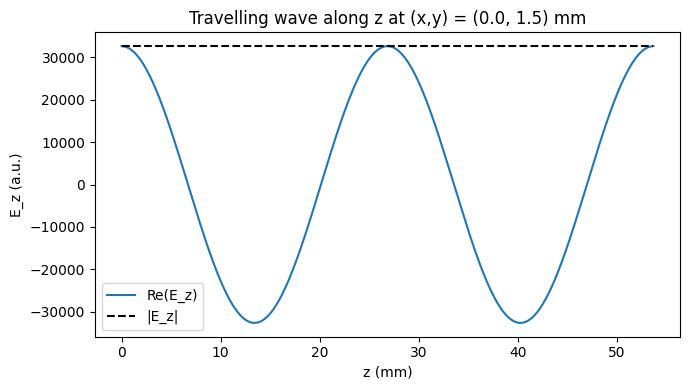

In [7]:
# Effect of the z-dependence exp(-j*beta*z): it is a pure travelling-wave phase
# factor, so it leaves |E_z| unchanged and just rotates the complex phasor;
# only the physical (real) part oscillates as the wave propagates along z.
z_vals = np.linspace(0, 4 * np.pi / beta_mn, 400)   # a couple of guide wavelengths
x0, y0 = 0.0, a / 2   # an arbitrary point in the vacuum region

E_z_point = get_field_components(m, beta_mn, frequency, np.array(x0), np.array(y0))[2]
E_z_z = add_z_dependence([np.full_like(z_vals, E_z_point, dtype=complex)], beta_mn, z_vals)[0]

plt.figure(figsize=(7, 4))
plt.plot(z_vals * 1e3, np.real(E_z_z), label="Re(E_z)")
plt.plot(z_vals * 1e3, np.abs(E_z_z), "k--", label="|E_z|")
plt.xlabel("z (mm)")
plt.ylabel("E_z (a.u.)")
plt.title(f"Travelling wave along z at (x,y) = ({x0*1e3:.1f}, {y0*1e3:.1f}) mm")
plt.legend()
plt.tight_layout()
plt.savefig("Ez_vs_z.png", dpi=150)
print("saved Ez_vs_z.png")


### Verification of LSM solution
To verify the solutions, I checked against Maxwell equations + boundary conditions for dielectric/vacuum interfaces

In [ ]:
# Verification of LSM solution
#   1. Boundary / interface conditions (uses the *exact* root of Eq. 4a)
#   2. Maxwell's equations by finite differences, inside each region
#   3. Limiting cases with closed-form answers (eps_r=1, a->0, d->0)
from contextlib import contextmanager
from scipy.constants import mu_0

_TOL_BC = 1e-6      # boundary / interface mismatch, relative to max|field|
_TOL_MAXWELL = 1e-3  # finite-difference residual at the finest grid
_TOL_LIMIT = 1e-3    # relative error vs analytic limit

def _status(ok):
    return "PASS" if ok else "FAIL"

@contextmanager
def _geometry(**kw):
    """
    Temporarily change eps_r / a (d = b - a follows) for the solver globals.
    """
    g = globals()
    old = {key: g[key] for key in ("eps_r", "a", "d")}
    g.update(kw)
    if "a" in kw and "d" not in kw:
        g["d"] = b - g["a"]
    try:
        yield
    finally:
        g.update(old)


def _beta_exact(f, m_, n_, func=lsm):
    """
    beta of mode (m_, n_) at frequency f from the roots of the dispersion relation.
    """
    k_ = 2 * np.pi * f / c
    roots = roots_in_s(func, k_)
    if len(roots) < n_:
        return np.nan
    beta2 = k_**2 - (m_ * np.pi / w) ** 2 - roots[n_ - 1]
    return np.sqrt(beta2) if beta2 > 0 else np.nan


def _analytic_beta(f, m_, n_, eps):
    """
    Guide with uniform permittivity eps, symmetry at y=0 and E_x=0 at y=b.
    """
    k_ = 2 * np.pi * f / c
    beta2 = eps * k_**2 - (m_ * np.pi / w) ** 2 - ((n_ - 0.5) * np.pi / b) ** 2
    return np.sqrt(beta2) if beta2 > 0 else np.nan


def _analytic_cutoff(m_, n_, eps):
    return c / (2 * np.pi * np.sqrt(eps)) * np.sqrt((m_ * np.pi / w) ** 2 + ((n_ - 0.5) * np.pi / b) ** 2)


# --------------------------------------------------------------------------
# 1. Boundary and interface conditions
# --------------------------------------------------------------------------
def check_boundary_conditions(f, beta, m_):
    """
    Check boundary and interface conditions for the LSM_mn mode at frequency f.
    """
    # define the x and y grids for the field evaluation, and a small gap to evaluate the fields 
    # just below and above the dielectric interface
    x = np.linspace(-w / 2, w / 2, 201)
    y = np.linspace(0, b, 401)
    gap = 1e-12

    lo = get_field_components(m_, beta, f, x, np.full_like(x, a - gap))   # vacuum side
    hi = get_field_components(m_, beta, f, x, np.full_like(x, a + gap))   # dielectric side
    E_scale = max(np.max(np.abs(F)) for F in (lo[:3] + hi[:3]))
    H_scale = max(np.max(np.abs(F)) for F in (lo[3:] + hi[3:]))

    # define a function to calculate the relative error between two field components, 
    # normalized by a scale factor s
    err = lambda u, v, s: np.max(np.abs(u - v)) / s

    # calculate the relative errors for the boundary and interface conditions, and store them 
    # in a dictionary
    res = {
        "y=a: E_x continuous": err(lo[0], hi[0], E_scale),
        "y=a: E_z continuous": err(lo[2], hi[2], E_scale),
        "y=a: eps_r*E_y(diel) = E_y(vac)": err(lo[1], eps_r * hi[1], E_scale),
        "y=a: H_x continuous": err(lo[3], hi[3], H_scale),
        "y=a: H_z continuous": err(lo[5], hi[5], H_scale),
    }

    # calculate the relative errors for the boundary conditions at y=b and x=0/w, 
    # and store them in the dictionary
    top = get_field_components(m_, beta, f, x, np.full_like(x, b))
    res["y=b: E_x = 0"] = np.max(np.abs(top[0])) / E_scale
    res["y=b: E_z = 0"] = np.max(np.abs(top[2])) / E_scale

    # calculate the relative errors for the boundary conditions at x=0 and x=w,
    for xw, label in ((-w / 2, "x=0"), (w / 2, "x=w")):
        side = get_field_components(m_, beta, f, np.full_like(y, xw), y)
        res[f"{label}: E_y = 0"] = np.max(np.abs(side[1])) / E_scale
        res[f"{label}: E_z = 0"] = np.max(np.abs(side[2])) / E_scale
        res[f"{label}: H_x = 0"] = np.max(np.abs(side[3])) / H_scale

    # print the results of the boundary and interface condition checks, and return True if all 
    # conditions are satisfied within the specified tolerance
    print("1. Boundary / interface conditions (tolerance %.0e)" % _TOL_BC)
    for key, val in res.items():
        print(f"   {_status(val < _TOL_BC)}  {key:34s} {val:.2e}")

    # informational: what the y=0 plane is
    bot = get_field_components(m_, beta, f, x, np.zeros_like(x))
    print("   info  y=0: max|E_x|, max|E_z|, max|H_z| / scale = "
          f"{np.max(np.abs(bot[0]))/E_scale:.2e}, {np.max(np.abs(bot[2]))/E_scale:.2e}, "
          f"{np.max(np.abs(bot[5]))/H_scale:.2e}")
    print("         (E_x, E_z != 0 and H_z = 0 means y=0 is a symmetry plane (PMC), not a metal wall)")
    return all(v < _TOL_BC for v in res.values())


# --------------------------------------------------------------------------
# 2. Maxwell's equations by finite differences, check residuals (time convention exp(+j w t))
# --------------------------------------------------------------------------
def _maxwell_residuals(f, beta, m_, n_pts):
    """
    Calculates Maxwell's equations on a grid that is n_pts large in the geometry of the waveguide
    specified by w, a, b. The dielectric is located a < y < b. Outputs the residuals of faraday's law, 
    ampere's law and div(D) in each region (vacuum and dielectric).

    f=frequency [Hz]
    beta=propagation constant [rad/m]
    m_=mode number in x
    n_pts=number of points in x and y to use for the finite difference grid
    
    Returns a dictionary with the residuals for each region for each Maxwell eqn
    """
    # define angular frequency, complex propagation constant and empty output dictionary, also define
    # regions for the dielectric and vacuum regions 
    omega_ = 2 * np.pi * f
    jb = 1j * beta
    out = {}
    regions = (("vacuum", 0.0, a * (1 - 1e-9), 1.0),
               ("dielectric", a * (1 + 1e-9), b, eps_r))

    # loop over the regions and calculate the field components, then calculate the curl of E and H, 
    # and finally calculate the residuals of Faraday's law, Ampere's law and div(D) in each region
    
    for name, y0, y1, eps in regions:
        x = np.linspace(-w / 2, w / 2, n_pts)
        y = np.linspace(y0, y1, n_pts)
        X, Y = np.meshgrid(x, y)
        Ex, Ey, Ez, Hx, Hy, Hz = get_field_components(m_, beta, f, X, Y)
        ddx = lambda F: np.gradient(F, x[1] - x[0], axis=1)
        ddy = lambda F: np.gradient(F, y[1] - y[0], axis=0)

        curlE = (ddy(Ez) + jb * Ey, -jb * Ex - ddx(Ez), ddx(Ey) - ddy(Ex))
        curlH = (ddy(Hz) + jb * Hy, -jb * Hx - ddx(Hz), ddx(Hy) - ddy(Hx))
        E, H = (Ex, Ey, Ez), (Hx, Hy, Hz)
        inner = (slice(1, -1), slice(1, -1))      # drop one-sided edge differences

        faraday = max(np.max(np.abs((curlE[i] + 1j * omega_ * mu_0 * H[i])[inner])) for i in range(3))
        faraday /= max(np.max(np.abs(omega_ * mu_0 * H[i])) for i in range(3))
        ampere = max(np.max(np.abs((curlH[i] - 1j * omega_ * epsilon_0 * eps * E[i])[inner])) for i in range(3))
        ampere /= max(np.max(np.abs(omega_ * epsilon_0 * eps * E[i])) for i in range(3))
        divD = np.max(np.abs((ddx(Ex) + ddy(Ey) - jb * Ez)[inner]))
        divD /= max(np.max(np.abs(ddx(Ex))), np.max(np.abs(ddy(Ey))), np.max(np.abs(beta * Ez)))
        out[name] = (faraday, ampere, divD)
    return out


def check_maxwell(f, beta, m_):
    """
    Check Maxwell's equations by finite differences, inside each region.
    """
    # define print statement for results and calculate the residuals for coarse and fine grids
    print("2. Maxwell residuals, relative (tolerance %.0e at the finest grid)" % _TOL_MAXWELL)
    coarse = _maxwell_residuals(f, beta, m_, 100)
    fine = _maxwell_residuals(f, beta, m_, 200)
    ok = True 

    # loopover the regions and equations, check if the residuals are below the tolerance, and print 
    # the results. print the ratio of the coarse and fine grid residuals, which should be ~4 for 
    # second-order finite differences
    for region in fine:
        for i, eq in enumerate(("curl E + jw mu0 H", "curl H - jw eps E", "div(eps E)")):
            r1, r2 = coarse[region][i], fine[region][i]
            good = r2 < _TOL_MAXWELL
            ok &= good
            ratio = r1 / r2 if r2 > 0 else np.inf
            print(f"   {_status(good)}  {region:10s} {eq:18s} N=100: {r1:.2e}  N=200: {r2:.2e}  (ratio {ratio:.1f}, ~4 expected)")
    return ok


# --------------------------------------------------------------------------
# 3. Limiting cases
# --------------------------------------------------------------------------
def check_limits(m_, n_modes=(1, 2, 3), f_factors=(1.1, 1.5, 2.5)):
    """
    Check the limiting cases of the LSM solution against closed-form results:
        eps_r = 1 (empty guide)
        a -> 0 (fully filled)
        d -> 0 (empty again)
    """
    print("3. Limiting cases vs closed-form results (tolerance %.0e)" % _TOL_LIMIT)
    ok = True
    cases = (
        ("eps_r = 1 (empty guide)", dict(eps_r=1.0), 1.0),
        ("a -> 0 (fully filled)",   dict(a=1e-8),    eps_r),
        ("d -> 0 (empty again)",    dict(a=b - 1e-8), 1.0),
    )
    for label, params, eps_eff in cases:
        with _geometry(**params):
            f_ref = _analytic_cutoff(m_, 1, eps_eff)
            worst, nchk = 0.0, 0
            for fac in f_factors:
                f = fac * f_ref
                for n_ in n_modes:
                    ref = _analytic_beta(f, m_, n_, eps_eff)
                    if np.isnan(ref):
                        continue
                    got = _beta_exact(f, m_, n_)
                    rel = abs(got - ref) / ref if np.isfinite(got) else np.inf
                    worst, nchk = max(worst, rel), nchk + 1
            good = nchk > 0 and worst < _TOL_LIMIT
            ok &= good
            print(f"   {_status(good)}  beta, {label:26s} worst rel. error {worst:.2e} over {nchk} (f, n) points")

    # cutoff() for the empty guide (its search window assumes a and d are not tiny)
    with _geometry(eps_r=1.0):
        worst = max(abs(cutoff(lsm, m_, n_) - _analytic_cutoff(m_, n_, 1.0)) / _analytic_cutoff(m_, n_, 1.0)
                    for n_ in n_modes)
        good = worst < _TOL_LIMIT
        ok &= good
        print(f"   {_status(good)}  cutoff(), eps_r = 1{'':17s} worst rel. error {worst:.2e}")
    return ok


# --------------------------------------------------------------------------
# 3b. check bounds and consistency for the actual structure
# --------------------------------------------------------------------------
def check_bounds(m_, n_, f, beta_interp):
    print("3b. Consistency for the actual structure")
    k_ = 2 * np.pi * f / c
    ok = True

    beta_ex = _beta_exact(f, m_, n_)
    rel = abs(beta_interp - beta_ex) / beta_ex
    good = rel < 1e-2
    ok &= good
    print(f"   {_status(good)}  interpolated beta (beta_curve) vs exact root: {rel:.2e}")

    lo = _analytic_beta(f, m_, n_, 1.0)
    lo = 0.0 if np.isnan(lo) else lo
    hi = _analytic_beta(f, m_, n_, eps_r)
    good = lo <= beta_ex <= hi
    ok &= good
    print(f"   {_status(good)}  empty-guide beta {lo:.2f} <= beta {beta_ex:.2f} <= filled-guide beta {hi:.2f} rad/m")

    good = beta_ex < np.sqrt(eps_r) * k_
    ok &= good
    print(f"   {_status(good)}  beta < sqrt(eps_r)*k  ({beta_ex:.2f} < {np.sqrt(eps_r)*k_:.2f})")

    if use_light_line_frequency:
        rel = abs(beta_ex - k_) / k_
        good = rel < 1e-6
        ok &= good
        print(f"   {_status(good)}  at the light-line frequency beta = k: |beta-k|/k = {rel:.2e}")
    return ok


# --------------------------------------------------------------------------
# run everything for the mode / frequency selected in the field-components cell
# --------------------------------------------------------------------------
_beta = _beta_exact(frequency, m, n)
print(f"LSM{m}{n} at f = {frequency/1e9:.4f} GHz, exact beta = {_beta:.4f} rad/m\n")
_results = {
    "boundary / interface conditions": check_boundary_conditions(frequency, _beta, m),
    "Maxwell residuals": check_maxwell(frequency, _beta, m),
    "limiting cases": check_limits(m),
    "consistency / bounds": check_bounds(m, n, frequency, beta_mn),
}
print("\nSummary:")
for _name, _ok in _results.items():
    print(f"   {_status(_ok)}  {_name}")


LSM11 at f = 11.1672 GHz, exact beta = 234.0480 rad/m

1. Boundary / interface conditions (tolerance 1e-06)
   PASS  y=a: E_x continuous                4.77e-11
   PASS  y=a: E_z continuous                8.18e-11
   PASS  y=a: eps_r*E_y(diel) = E_y(vac)    3.45e-09
   PASS  y=a: H_x continuous                3.87e-09
   PASS  y=a: H_z continuous                2.26e-09
   PASS  y=b: E_x = 0                       0.00e+00
   PASS  y=b: E_z = 0                       0.00e+00
   PASS  x=0: E_y = 0                       0.00e+00
   PASS  x=0: E_z = 0                       0.00e+00
   PASS  x=0: H_x = 0                       0.00e+00
   PASS  x=w: E_y = 0                       1.09e-16
   PASS  x=w: E_z = 0                       1.22e-16
   PASS  x=w: H_x = 0                       6.37e-16
   info  y=0: max|E_x|, max|E_z|, max|H_z| / scale = 5.38e-01, 9.22e-01, 0.00e+00
         (E_x, E_z != 0 and H_z = 0 means y=0 is a symmetry plane (PMC), not a metal wall)
2. Maxwell residuals, relative